    Outlook Temperature Humidity   Windy Play
0     Sunny         Hot     High    Weak   No
1     Sunny         Hot     High  Strong   No
2  Overcast         Hot     High    Weak  Yes
3      Rain        Mild     High    Weak  Yes
4      Rain        Cool   Normal    Weak  Yes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temperature  14 non-null     object
 2   Humidity     14 non-null     object
 3   Windy        14 non-null     object
 4   Play         14 non-null     object
dtypes: object(5)
memory usage: 692.0+ bytes
None
       Outlook Temperature Humidity Windy Play
count       14          14       14    14   14
unique       3           3        2     2    2
top      Sunny        Mild     High  Weak  Yes
freq         5           6        7     8    9


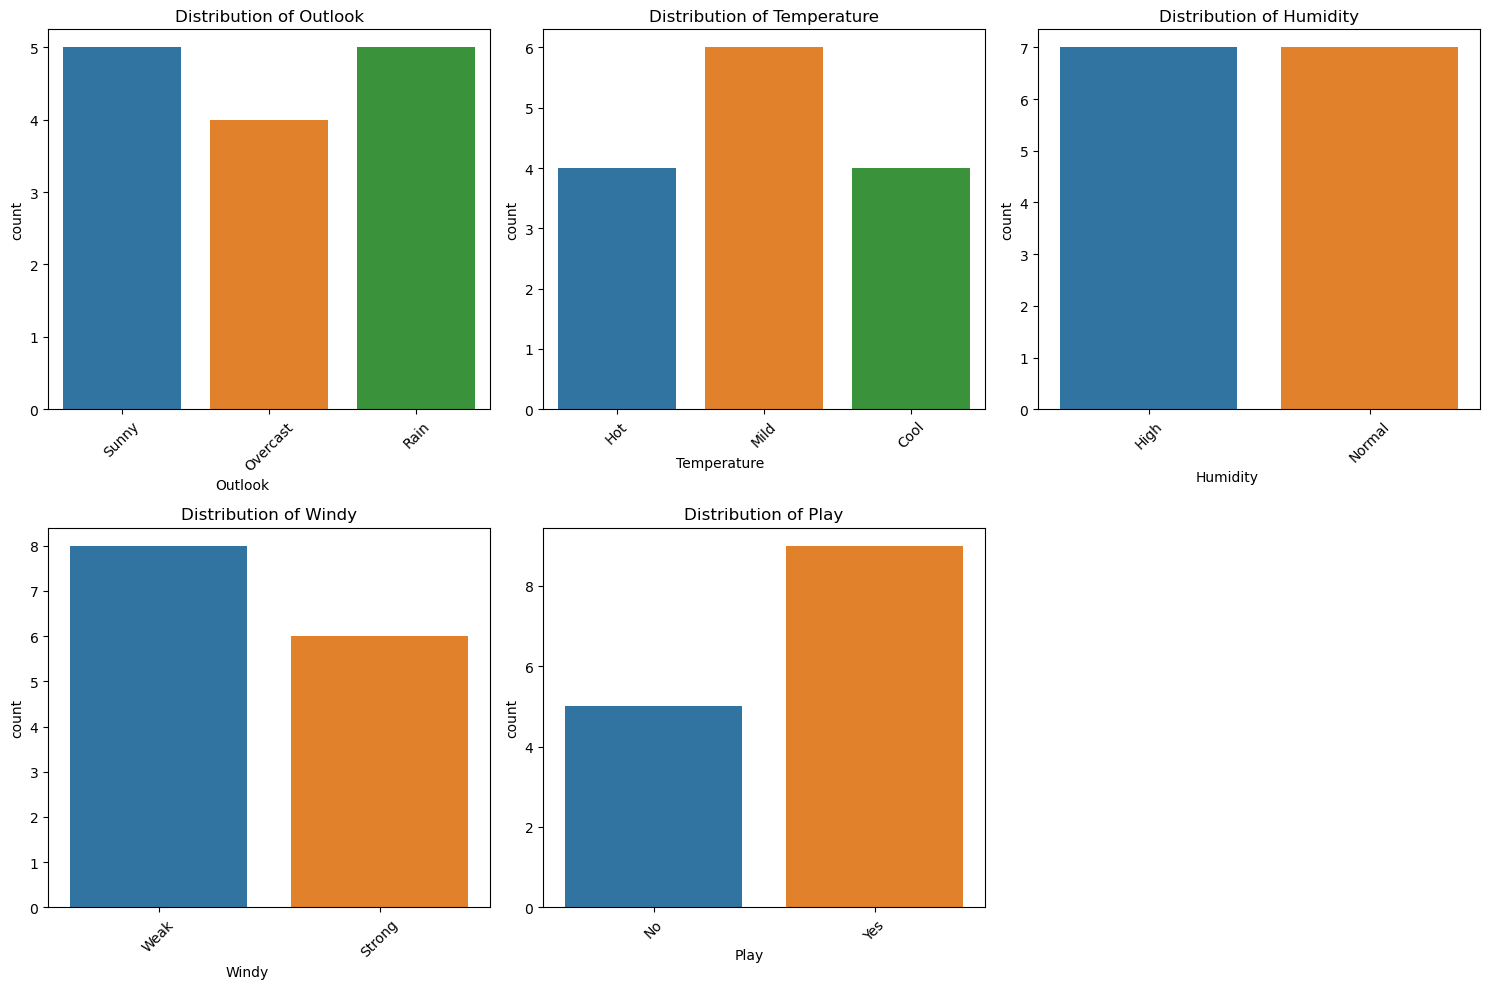

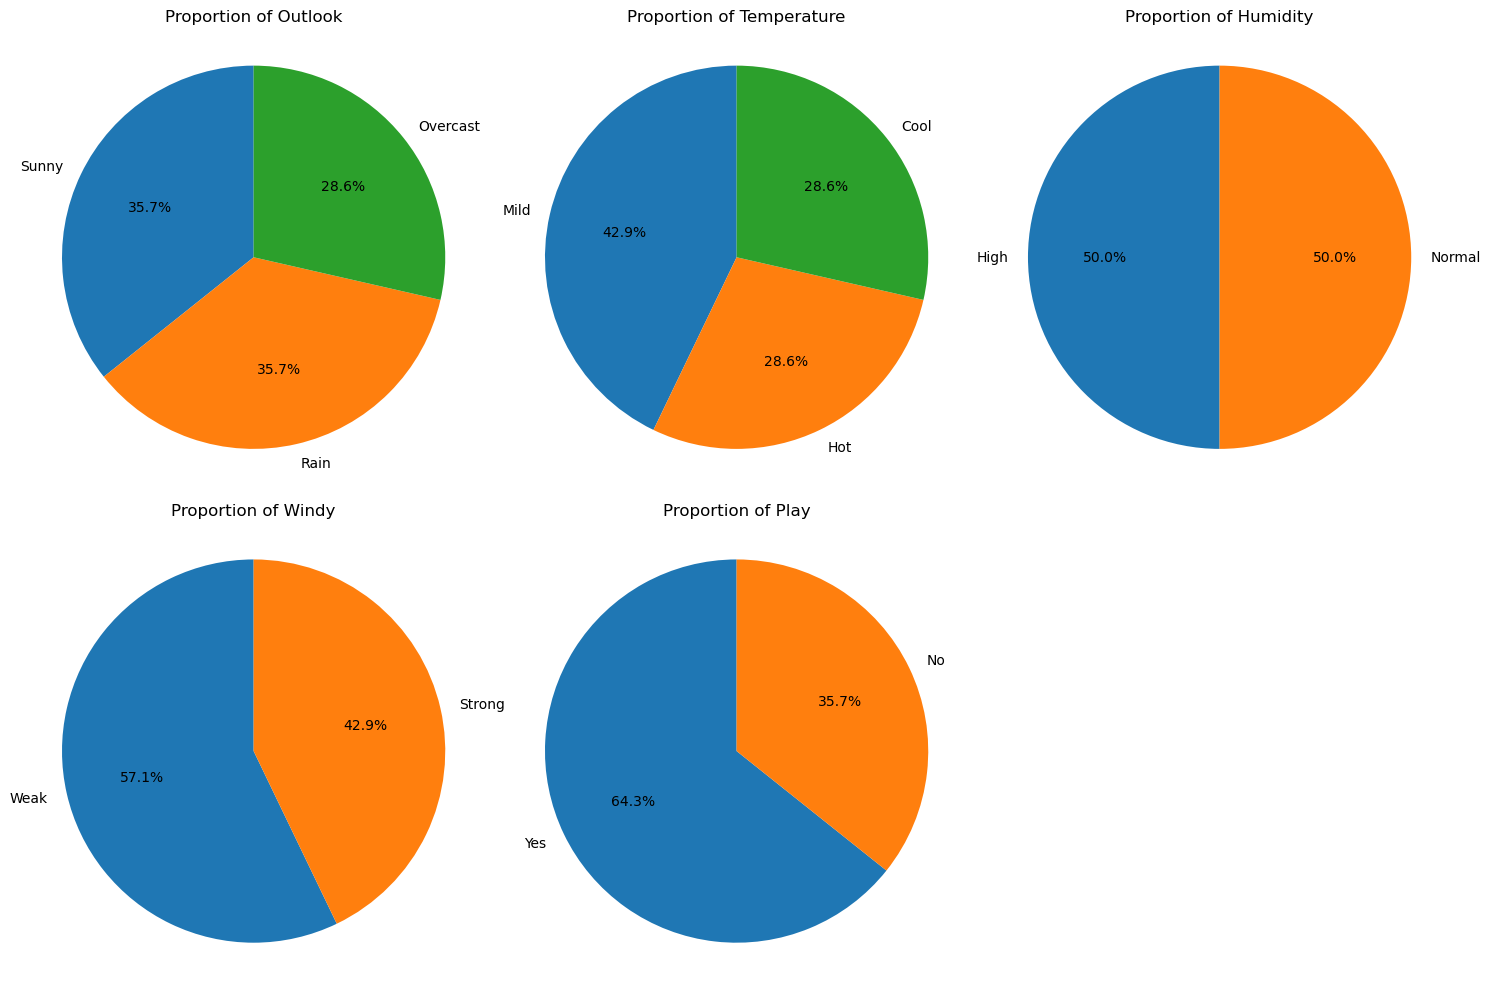

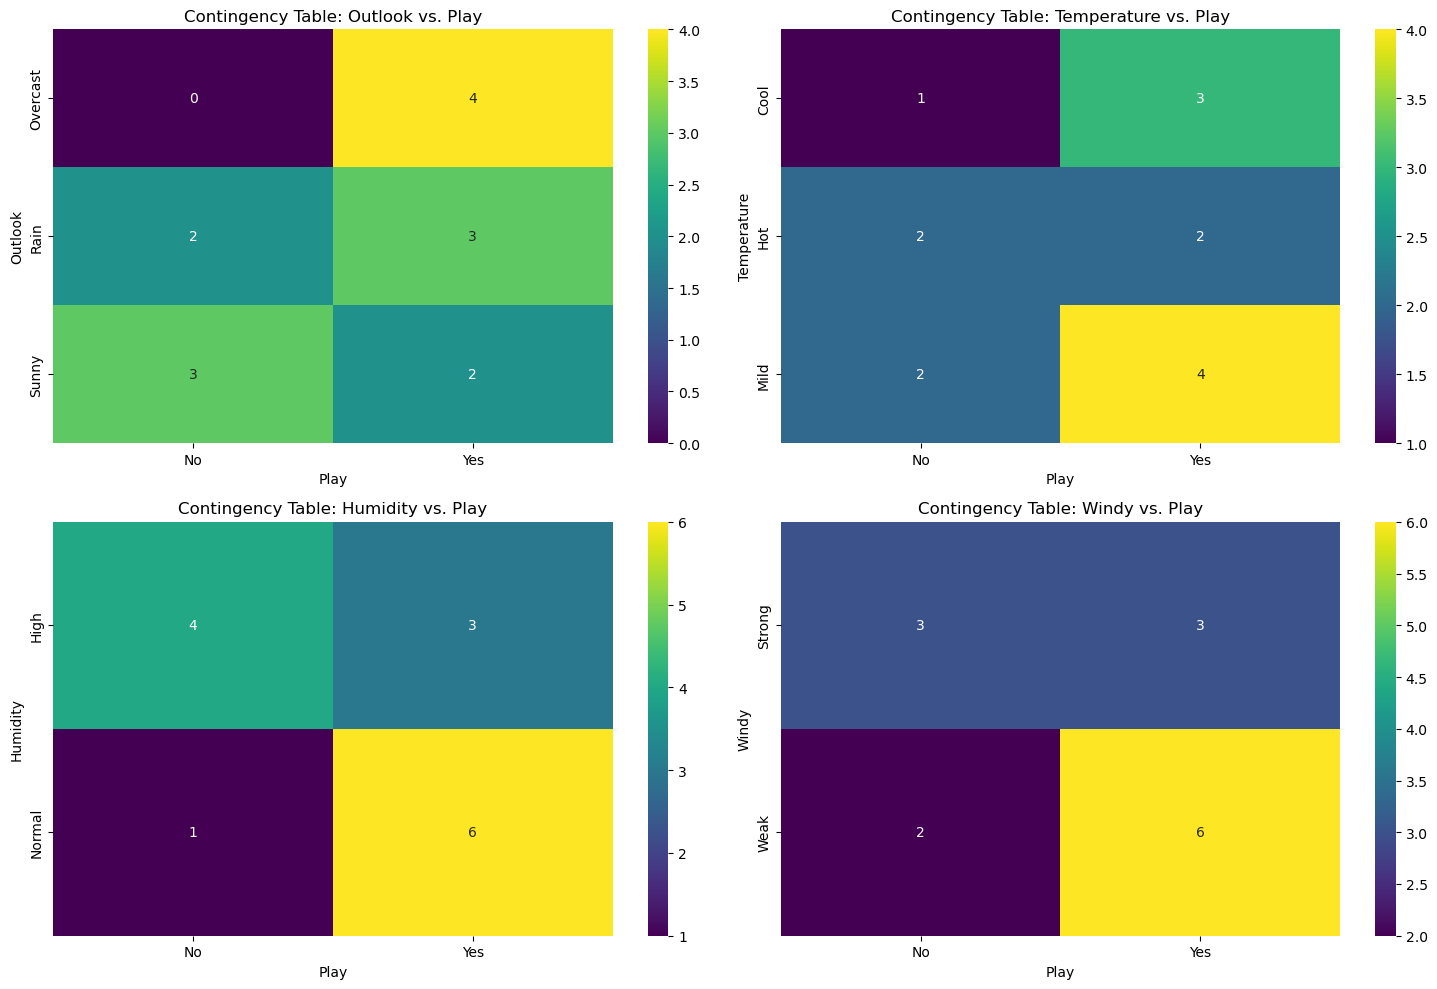

Accuracy:0.3333333333333333

Classification Report:
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         1
         Yes       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [30]:
#Importing necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

#Data preprocessing
data = pd.read_csv("weather_forecast.csv")
print(data.head(5))
print(data.info())
print(data.describe())

#Countplot
categorical_features = data.select_dtypes(include = ['object','category']).columns

num_features = len(categorical_features)
num_cols = 3
num_rows = (num_features+num_cols-1)//num_cols

fig,axes = plt.subplots(num_rows,num_cols,figsize = (15,5*num_rows))
axes = axes.flatten()

for i,feature in enumerate(categorical_features):
    sns.countplot(x = feature, data = data, ax = axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].tick_params(axis = 'x',rotation = 45)
    axes[i].xaxis.get_label().set_ha('right')

for i in range(num_features,num_rows*num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#Piechart
categorical_features = data.select_dtypes(include = ['object','category']).columns

num_features = len(categorical_features)
num_cols = 3
num_rows = (num_features+num_cols-1)//num_cols

fig,axes = plt.subplots(num_rows,num_cols,figsize = (15,5*num_rows))
axes = axes.flatten()

for i,feature in enumerate(categorical_features):
    feature_counts = data[feature].value_counts()
    axes[i].pie(feature_counts, labels=feature_counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Proportion of {feature}')
    axes[i].axis('equal')

for i in range(num_features,num_rows*num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#Contigency table
num_features = len(data.columns) - 1 
num_cols = 2  
num_rows = (num_features + num_cols - 1) // num_cols  

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows)) 
axes = axes.flatten() 

for i, feature in enumerate(data.columns):
    if feature != 'Play':
        contingency_table = pd.crosstab(data[feature], data['Play'])
        sns.heatmap(contingency_table, annot=True, cmap='viridis', fmt='d', ax=axes[i])
        axes[i].set_title(f'Contingency Table: {feature} vs. Play')

for i in range(num_features, num_rows * num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#Model selection
X = data.drop('Play',axis = 1)
y = data['Play']

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_encoded,y,test_size = 0.2,random_state = 42)

#Model evaluation
classifier = CategoricalNB()

classifier.fit(X_train,y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f"Accuracy:{accuracy}")
print(f"\nClassification Report:\n{report}")

In [31]:
import pandas as pd
import numpy as np

class NaiveBayesClassifier:
    def __init__(self):
        self.prior_probs = {}
        self.likelihood_probs = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for class_ in self.classes:
            self.prior_probs[class_] = len(y[y == class_]) / len(y)  # Calculate prior probabilities

            class_data = X[y == class_]
            for feature in X.columns:
                self.likelihood_probs[(feature, class_)] = {}  # Initialize likelihood probabilities
                for value in np.unique(X[feature]):
                    self.likelihood_probs[(feature, class_)][value] = (
                        len(class_data[class_data[feature] == value]) / len(class_data)
                    )  # Calculate likelihood probabilities

    def predict(self, X):
        predictions = []
        for _, row in X.iterrows():
            max_prob = -1
            predicted_class = None
            for class_ in self.classes:
                prob = self.prior_probs[class_]
                for feature in X.columns:
                    value = row[feature]
                    if (feature, class_) in self.likelihood_probs and value in self.likelihood_probs[(feature, class_)]:
                        prob *= self.likelihood_probs[(feature, class_)][value]
                    else:
                        prob *= 0.0001  # Handle unseen values with Laplace smoothing
                if prob > max_prob:
                    max_prob = prob
                    predicted_class = class_
            predictions.append(predicted_class)
        return np.array(predictions)
    

X = data.drop('Play',axis = 1)
y = data['Play']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifier = NaiveBayesClassifier()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f"Accuracy:{accuracy}")
print(f"\nClassification Report:\n{report}")

Accuracy:0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         1
         Yes       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


   Unnamed: 0 size   material   color sleeves  demand
0           0    S      nylon   white    long  medium
1           1   XL  polyester   cream   short    high
2           2    S       silk    blue   short  medium
3           3    M     cotton   black   short  medium
4           4   XL  polyester  orange    long  medium
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   size        10000 non-null  object
 2   material    10000 non-null  object
 3   color       10000 non-null  object
 4   sleeves     10000 non-null  object
 5   demand      10000 non-null  object
dtypes: int64(1), object(5)
memory usage: 468.9+ KB
None
        Unnamed: 0
count  10000.00000
mean    4999.50000
std     2886.89568
min        0.00000
25%     2499.75000
50%     4999.50000
75%     7499.25000
max     9999.00000


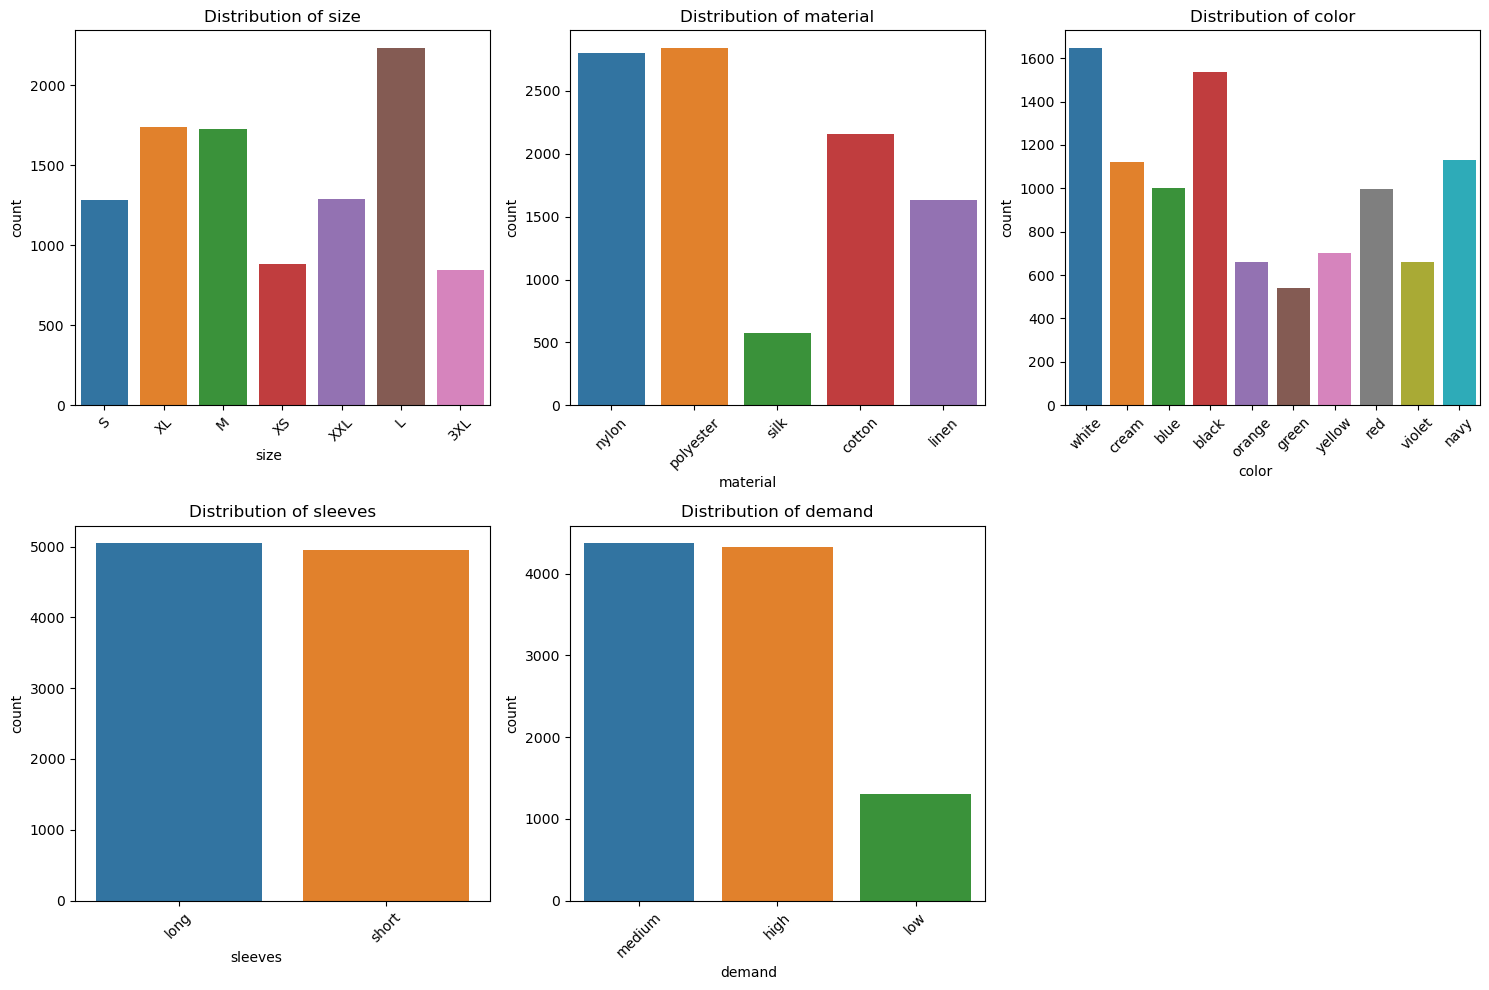

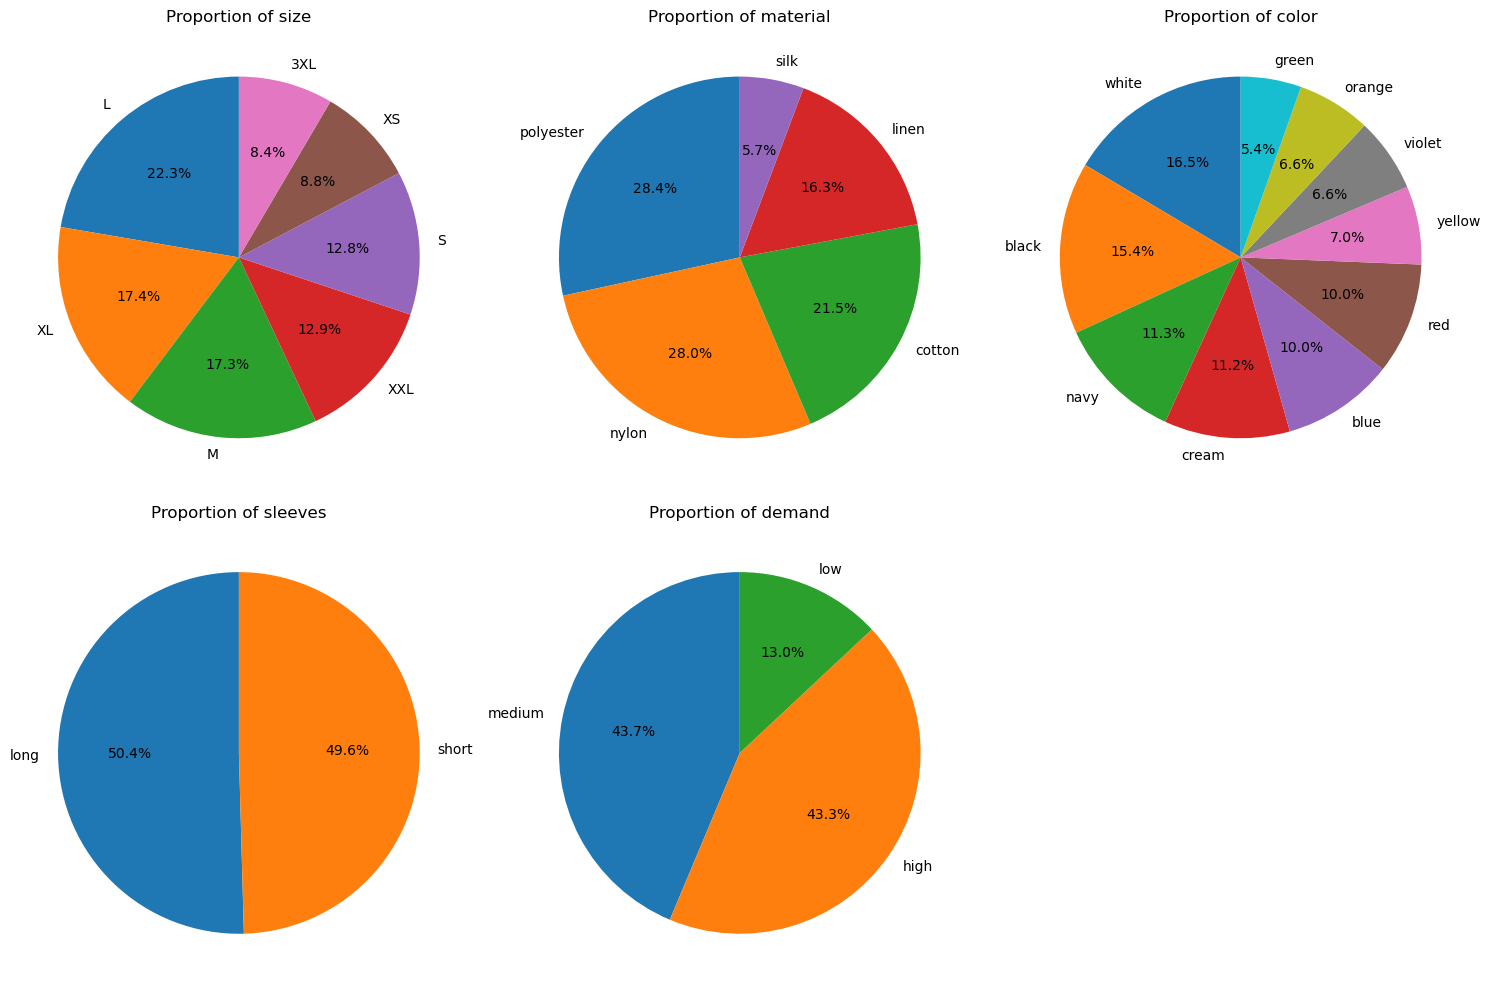

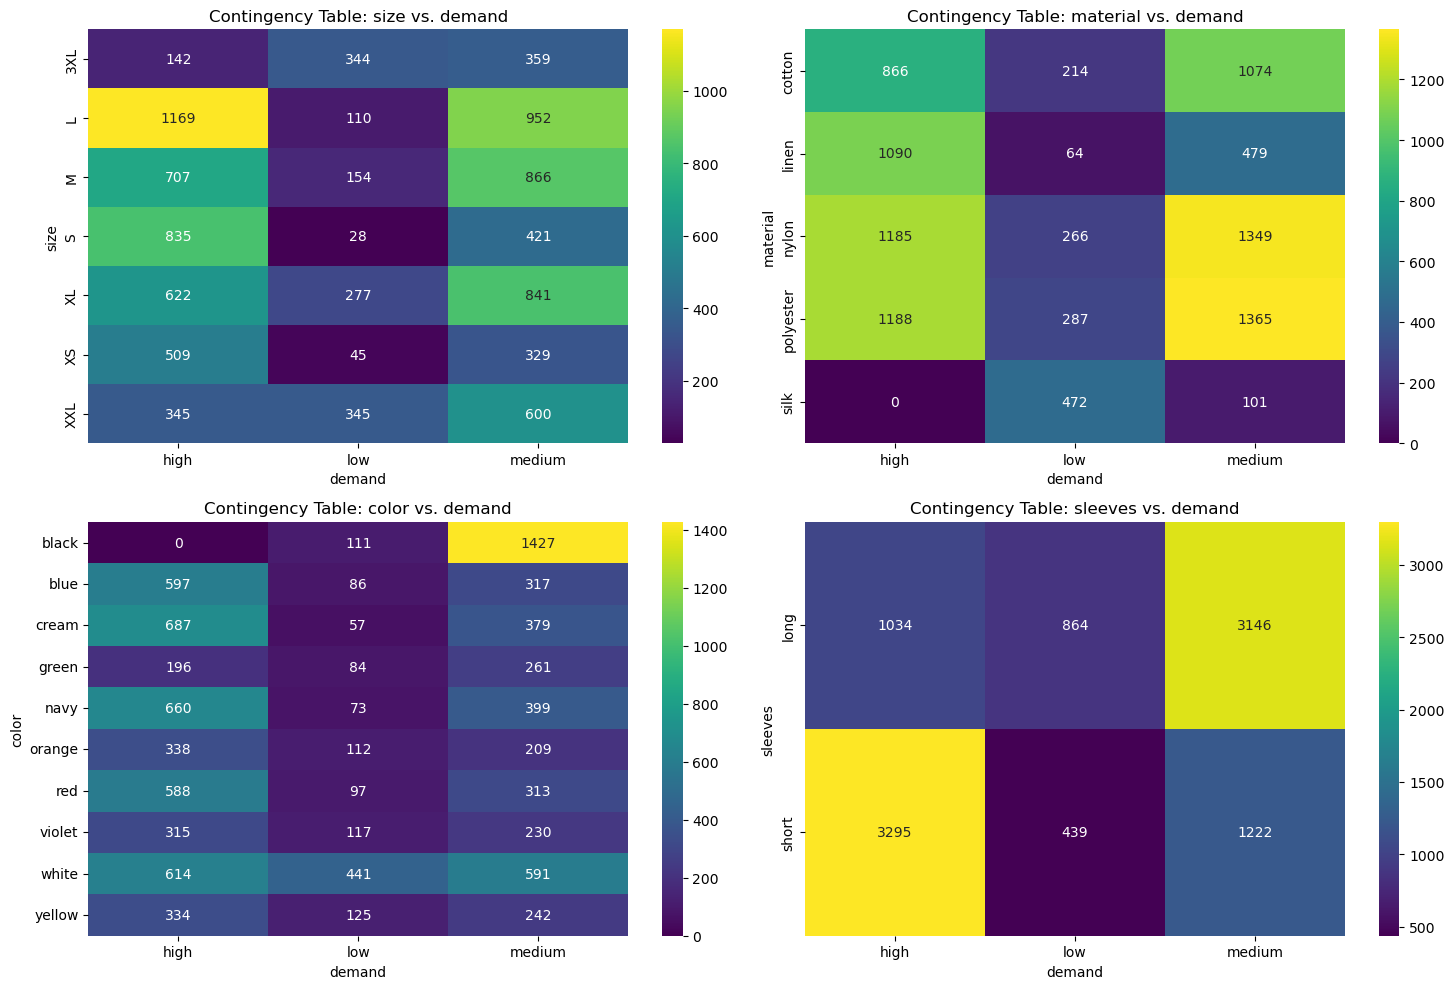

Accuracy:0.817

Classification Report:
              precision    recall  f1-score   support

        high       0.88      0.87      0.87       893
         low       0.75      0.53      0.62       258
      medium       0.77      0.85      0.81       849

    accuracy                           0.82      2000
   macro avg       0.80      0.75      0.77      2000
weighted avg       0.82      0.82      0.81      2000



In [35]:
#Importing necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

#Data preprocessing
df = pd.read_csv("categ.csv")
print(df.head(5))
print(df.info())
print(df.describe())

#Countplot
categorical_features = df.select_dtypes(include = ['object','category']).columns

num_features = len(categorical_features)
num_cols = 3
num_rows = (num_features+num_cols-1)//num_cols

fig,axes = plt.subplots(num_rows,num_cols,figsize = (15,5*num_rows))
axes = axes.flatten()

for i,feature in enumerate(categorical_features):
    sns.countplot(x = feature, data = df, ax = axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].tick_params(axis = 'x',rotation = 45)
    axes[i].xaxis.get_label().set_ha('right')

for i in range(num_features,num_rows*num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#Piechart
categorical_features = df.select_dtypes(include = ['object','category']).columns

num_features = len(categorical_features)
num_cols = 3
num_rows = (num_features+num_cols-1)//num_cols

fig,axes = plt.subplots(num_rows,num_cols,figsize = (15,5*num_rows))
axes = axes.flatten()

for i,feature in enumerate(categorical_features):
    feature_counts = df[feature].value_counts()
    axes[i].pie(feature_counts, labels=feature_counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Proportion of {feature}')
    axes[i].axis('equal')

for i in range(num_features,num_rows*num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#Contigency table
num_features = len(df.columns) - 2 
num_cols = 2  
num_rows = (num_features + num_cols - 1) // num_cols  

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows)) 
axes = axes.flatten() 

for i, feature in enumerate(df.columns[1:]):
    if feature != 'demand':
        contingency_table = pd.crosstab(df[feature], df['demand'])
        sns.heatmap(contingency_table, annot=True, cmap='viridis', fmt='d', ax=axes[i])
        axes[i].set_title(f'Contingency Table: {feature} vs. demand')

for i in range(num_features, num_rows * num_cols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#Model selection
X = df.drop('demand',axis = 1)
y = df['demand']

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_encoded,y,test_size = 0.2,random_state = 42)

#Model evaluation
classifier = CategoricalNB()

classifier.fit(X_train,y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f"Accuracy:{accuracy}")
print(f"\nClassification Report:\n{report}")

In [24]:
import pandas as pd
import numpy as np

class NaiveBayesClassifier:
    def __init__(self):
        self.prior_probs = {}
        self.likelihood_probs = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for class_ in self.classes:
            self.prior_probs[class_] = len(y[y == class_]) / len(y)  # Calculate prior probabilities

            class_data = X[y == class_]
            for feature in X.columns:
                self.likelihood_probs[(feature, class_)] = {}  # Initialize likelihood probabilities
                for value in np.unique(X[feature]):
                    self.likelihood_probs[(feature, class_)][value] = (
                        len(class_data[class_data[feature] == value]) / len(class_data)
                    )  # Calculate likelihood probabilities

    def predict(self, X):
        predictions = []
        for _, row in X.iterrows():
            max_prob = -1
            predicted_class = None
            for class_ in self.classes:
                prob = self.prior_probs[class_]
                for feature in X.columns:
                    value = row[feature]
                    if (feature, class_) in self.likelihood_probs and value in self.likelihood_probs[(feature, class_)]:
                        prob *= self.likelihood_probs[(feature, class_)][value]
                    else:
                        prob *= 0.0001  # Handle unseen values with Laplace smoothing
                if prob > max_prob:
                    max_prob = prob
                    predicted_class = class_
            predictions.append(predicted_class)
        return np.array(predictions)
    

X = df.drop('demand',axis = 1)
y = df['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifier = NaiveBayesClassifier()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred)

print(f"Accuracy:{accuracy}")
print(f"\nClassification Report:\n{report}")

Accuracy:0.816

Classification Report:
              precision    recall  f1-score   support

        high       0.87      0.87      0.87       893
         low       0.86      0.46      0.60       258
      medium       0.76      0.87      0.81       849

    accuracy                           0.82      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.82      0.82      0.81      2000

